#  Palestine Tourism Dataset — Exploratory Data Analysis (EDA)

**Project:** AI Travel Squad — Content-Based Recommendation System  
**Dataset:** `palestine_tourist_attractions_v2.csv` — 331 tourist places across 10 Palestinian cities  
**Goal:** Understand the data structure, distributions, and key patterns before building the recommendation model.

---

###  Table of Contents
1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [City Distribution](#3)
4. [Place Type Distribution](#4)
5. [Feature Distributions](#5)
6. [City × Trip Type Heatmap](#6)
7. [Cost Analysis](#7)
8. [Budget Mix per City](#8)
9. [Free Places Analysis](#9)
10. [Key Insights & Implications](#10)

## 1. Setup & Data Loading <a id='1'></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── Style Configuration ──────────────────────────────────────────────────
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 130

PALETTE = [
    '#2D6A4F', '#52B788', '#95D5B2', '#D8F3DC',
    '#40916C', '#1B4332', '#74C69D', '#B7E4C7',
    '#081C15', '#AACC00'
]
sns.set_style('whitegrid')

# ─── Load Dataset ─────────────────────────────────────────────────────────
df = pd.read_csv('E:\AI-Travel-Squad\AI&ML\Code\Data\palestine_tourist_attractions_v2.csv')
print(f' Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')

 Dataset loaded: 331 rows × 13 columns


## 2. Dataset Overview <a id='2'></a>

We start with the basics: shape, data types, and completeness.
A clean dataset is the foundation of any reliable model.

In [3]:
# ─── Basic Info ───────────────────────────────────────────────────────────
print('=== Dataset Shape ===')
print(f'  Rows    : {df.shape[0]}')
print(f'  Columns : {df.shape[1]}')

print('\n=== Column Types ===')
print(df.dtypes.to_string())

print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else '   No missing values!')

print('\n=== First 3 Rows ===')
df.head(3)

=== Dataset Shape ===
  Rows    : 331
  Columns : 13

=== Column Types ===
ID                      int64
Place_Name                str
type                      str
City                      str
Budget_Level              str
Age_Group                 str
Trip_Type                 str
Description               str
Latitude              float64
Longitude             float64
Coordinate_Source         str
Geocode_Status            str
Estimated_Cost_ILS      int64

=== Missing Values ===
   No missing values!

=== First 3 Rows ===


,ID,Place_Name,type,City,Budget_Level,Age_Group,Trip_Type,Description,Latitude,Longitude,Coordinate_Source,Geocode_Status,Estimated_Cost_ILS
0,1,Mosque of 'Umar Ibn al-Khattab (Qalqilya),Religious,Qalqilya,Medium,All,Religious,The Mosque of Umar Ibn al-Khattab (Qalqilya) i...,32.190557,34.966009,OpenStreetMap Photon (city centroid fallback),City-level,55
1,2,Al-Far'a Tower,Historic Old City,Tubas,Medium,All,Cultural,Al-Far'a Tower is a historic watchtower struct...,32.323439,35.369366,OpenStreetMap Photon (city centroid fallback),City-level,60
2,3,Khirbet Keshda (Ruin),Archaeological,Tubas,Low,Youth,Adventure,Khirbet Keshda is an archaeological ruin site ...,32.323439,35.369366,OpenStreetMap Photon (city centroid fallback),City-level,10


In [4]:
# ─── Numeric Summary ──────────────────────────────────────────────────────
print('=== Estimated Cost (ILS) — Summary Statistics ===')
print(df['Estimated_Cost_ILS'].describe().round(2))

print('\n=== Unique Values per Categorical Column ===')
for col in ['City', 'type', 'Trip_Type', 'Budget_Level', 'Age_Group']:
    print(f'  {col:15} → {df[col].nunique()} unique: {df[col].unique().tolist()}')

=== Estimated Cost (ILS) — Summary Statistics ===
count    331.00
mean      23.73
std       25.66
min        0.00
25%        0.00
50%       20.00
75%       40.00
max      145.00
Name: Estimated_Cost_ILS, dtype: float64

=== Unique Values per Categorical Column ===
  City            → 10 unique: ['Qalqilya', 'Tubas', 'Jenin', 'Tulkarm', 'Nablus', 'Jerusalem', 'Bethlehem', 'Jericho', 'Hebron', 'Ramallah']
  type            → 9 unique: ['Religious', 'Historic Old City', 'Archaeological', 'Museum', 'Family/Recreational', 'Nature & Trails', 'Education', 'Historic', 'Cultural']
  Trip_Type       → 6 unique: ['Religious', 'Cultural', 'Adventure', 'Family', 'Relaxing', 'Educational']
  Budget_Level    → 3 unique: ['Medium', 'Low', 'High']
  Age_Group       → 3 unique: ['All', 'Youth', 'Family']


### Key Observations
- **No missing values** — the dataset is fully complete, no imputation needed.
- **Estimated_Cost_ILS** ranges from **0 to 145 ILS** with a mean of ~24 ILS, suggesting most places are affordable or free.
- There are **10 cities**, **9 place types**, **6 trip types**, **3 budget levels**, and **3 age groups** — all categorical features suitable for One-Hot Encoding.

## 3. City Distribution <a id='3'></a>

Understanding how places are spread across cities reveals coverage gaps and data imbalance that directly affects recommendation quality.

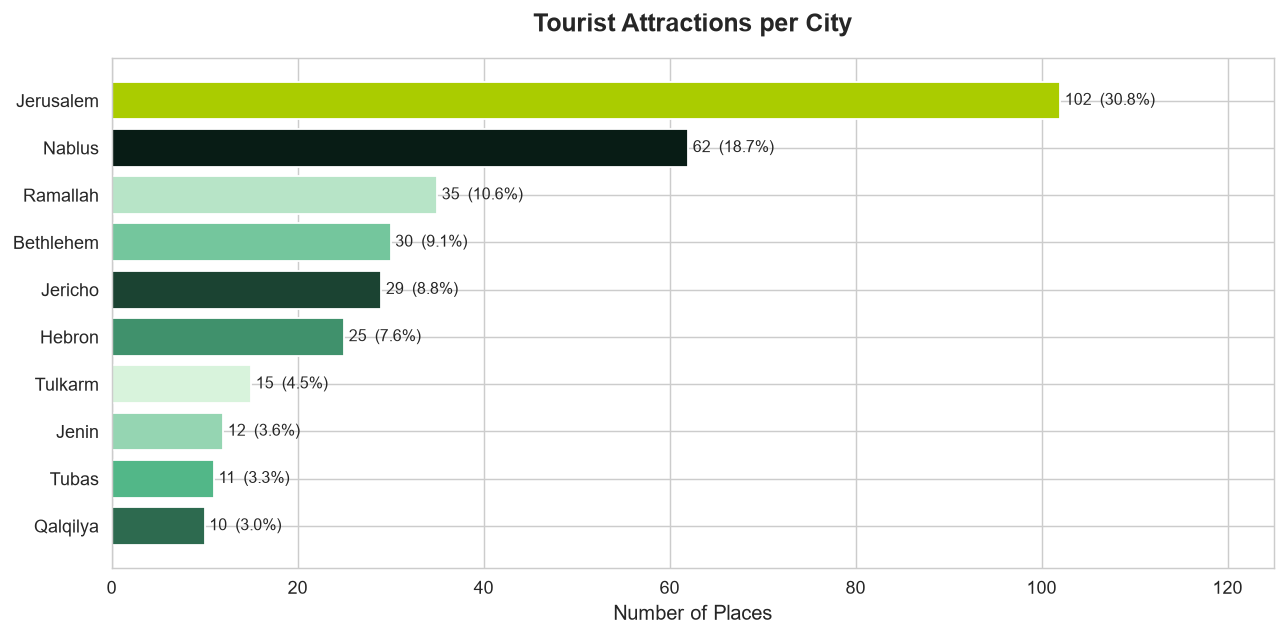

City
Jerusalem    102
Nablus        62
Ramallah      35
Bethlehem     30
Jericho       29
Hebron        25
Tulkarm       15
Jenin         12
Tubas         11
Qalqilya      10


In [5]:
city_counts = df['City'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    city_counts.index[::-1],
    city_counts.values[::-1],
    color=PALETTE[:len(city_counts)]
)

for bar, val in zip(bars, city_counts.values[::-1]):
    ax.text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
        f'{val}  ({val/len(df)*100:.1f}%)',
        va='center', fontsize=9
    )

ax.set_xlabel('Number of Places', fontsize=11)
ax.set_title('Tourist Attractions per City', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 125)
plt.tight_layout()
plt.show()

print(city_counts.to_string())

###  Key Observations
- **Jerusalem dominates** with 102 places (30.8%) — nearly 1 in 3 attractions is in Jerusalem.
- **Nablus** is second with 62 places (18.7%), making it a strong candidate for diverse recommendations.
- **Qalqilya (10) and Tubas (11)** are underrepresented — the model may return fewer recommendations for users selecting these cities.
- This imbalance is an important consideration: the recommendation system will naturally perform better for cities with more data.

## 4. Place Type Distribution <a id='4'></a>

Place types define what kind of experience each location offers. Understanding their distribution tells us which categories the model can recommend confidently.

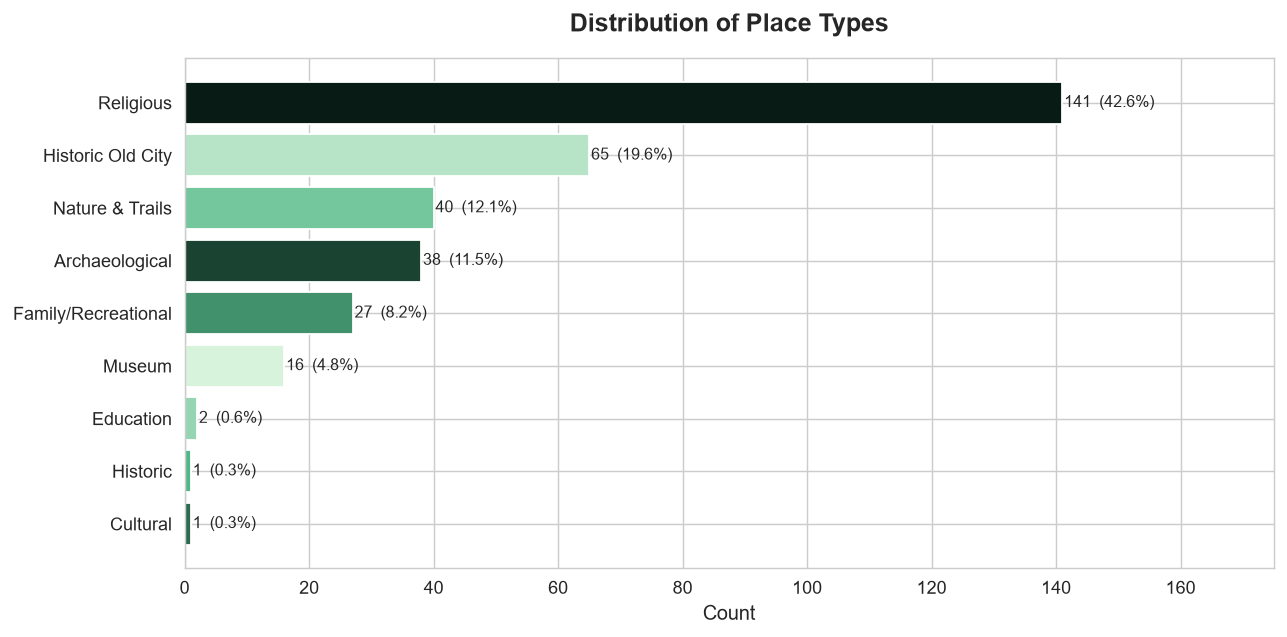

In [6]:
type_counts = df['type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    type_counts.index[::-1],
    type_counts.values[::-1],
    color=PALETTE[:len(type_counts)]
)

for bar, val in zip(bars, type_counts.values[::-1]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{val}  ({val/len(df)*100:.1f}%)',
        va='center', fontsize=9
    )

ax.set_xlabel('Count', fontsize=11)
ax.set_title('Distribution of Place Types', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 175)
plt.tight_layout()
plt.show()

###  Key Observations
- **Religious** places are the majority (141, 42.6%) — Palestine's deep historical and spiritual significance is reflected clearly.
- **Historic Old City** (65, 19.6%) and **Nature & Trails** (40, 12.1%) are the next strongest categories.
- **Education** (2) and **Historic** (1) and **Cultural** (1) are extremely rare — the model should handle these edge cases carefully.
- The class imbalance means that if a user selects a rare trip type, the system will have limited options to recommend.

## 5. Feature Distributions <a id='5'></a>

Exploring Trip Type, Budget Level, and Age Group — the three main user inputs in the recommendation system.

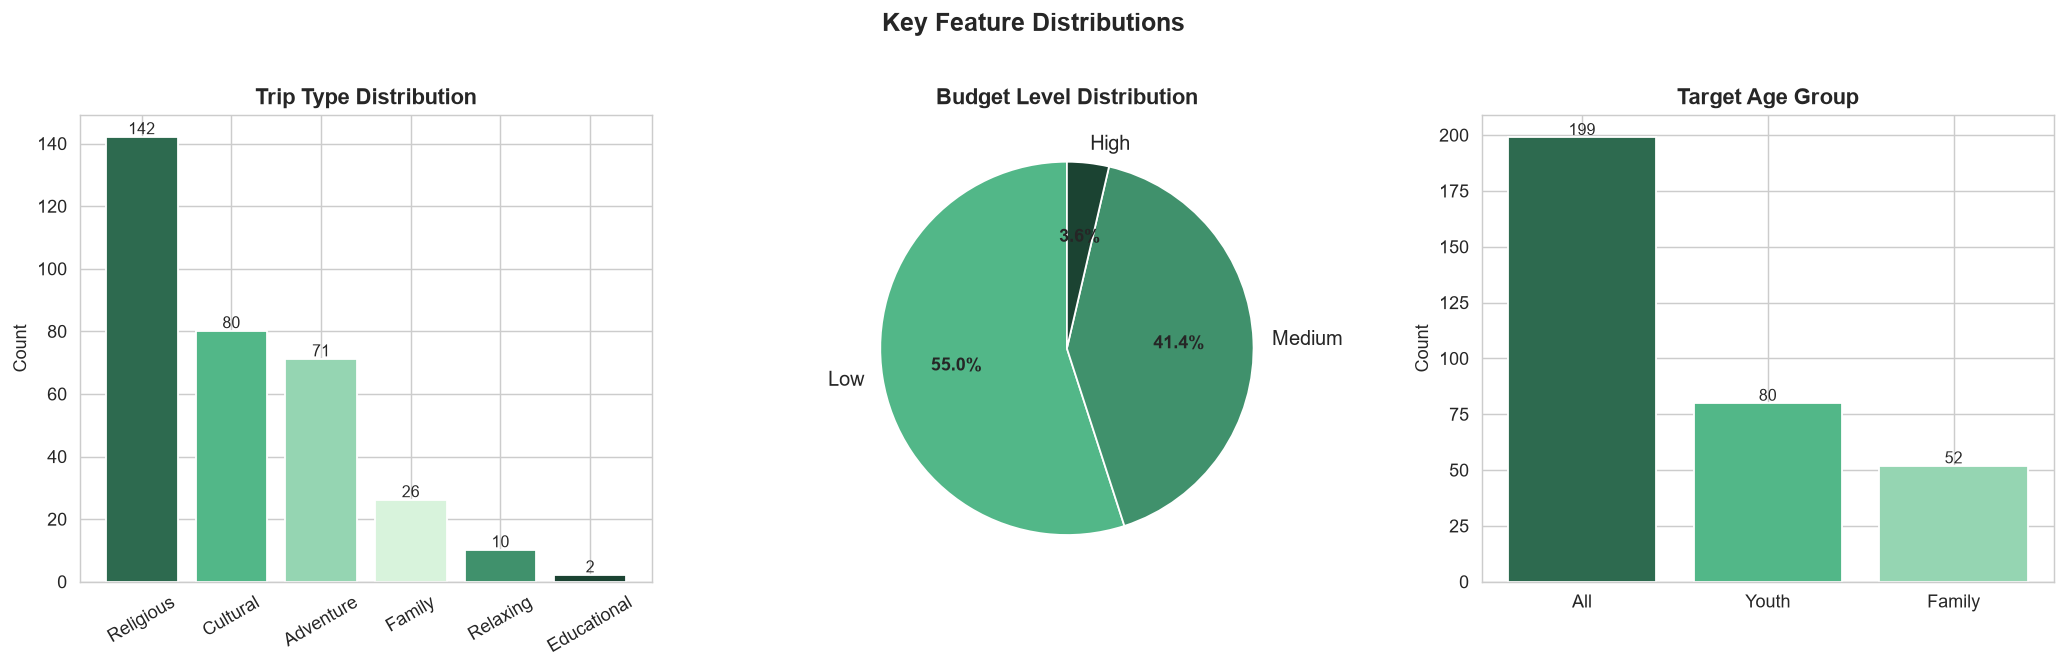

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Trip Type ─────────────────────────────────────────────────────────────
trip_counts = df['Trip_Type'].value_counts()
axes[0].bar(trip_counts.index, trip_counts.values, color=PALETTE[:len(trip_counts)])
axes[0].set_title('Trip Type Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, (idx, val) in enumerate(trip_counts.items()):
    axes[0].text(i, val + 1, str(val), ha='center', fontsize=9)

# ── Budget Level ──────────────────────────────────────────────────────────
budget_counts = df['Budget_Level'].value_counts()
budget_colors = {'Low': '#52B788', 'Medium': '#40916C', 'High': '#1B4332'}
bar_colors = [budget_colors[b] for b in budget_counts.index]
wedges, texts, autotexts = axes[1].pie(
    budget_counts.values,
    labels=budget_counts.index,
    autopct='%1.1f%%',
    colors=bar_colors,
    startangle=90,
    textprops={'fontsize': 11}
)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
axes[1].set_title('Budget Level Distribution', fontsize=12, fontweight='bold')

# ── Age Group ─────────────────────────────────────────────────────────────
age_counts = df['Age_Group'].value_counts()
axes[2].bar(age_counts.index, age_counts.values, color=PALETTE[:len(age_counts)])
axes[2].set_title('Target Age Group', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count')
for i, (idx, val) in enumerate(age_counts.items()):
    axes[2].text(i, val + 1, str(val), ha='center', fontsize=9)

plt.suptitle('Key Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

###  Key Observations
- **Trip Type:** Religious (142) and Cultural (80) dominate. Relaxing (10) and Educational (2) are rare — the model needs to handle sparse categories gracefully.
- **Budget Level:** The dataset is skewed toward **Low (55%)** and **Medium (41.4%)** — only 3.6% of places are classified as High budget. This reflects real accessibility in Palestinian tourism.
- **Age Group:** 60.1% of places are labeled 'All', meaning they suit every demographic. Only 15.7% are specifically 'Family'-oriented, which could limit family-specific recommendations.

## 6. City × Trip Type Heatmap <a id='6'></a>

This heatmap reveals which combinations of city and trip type are well-represented in the dataset — directly predicting where the recommendation model will perform well or struggle.

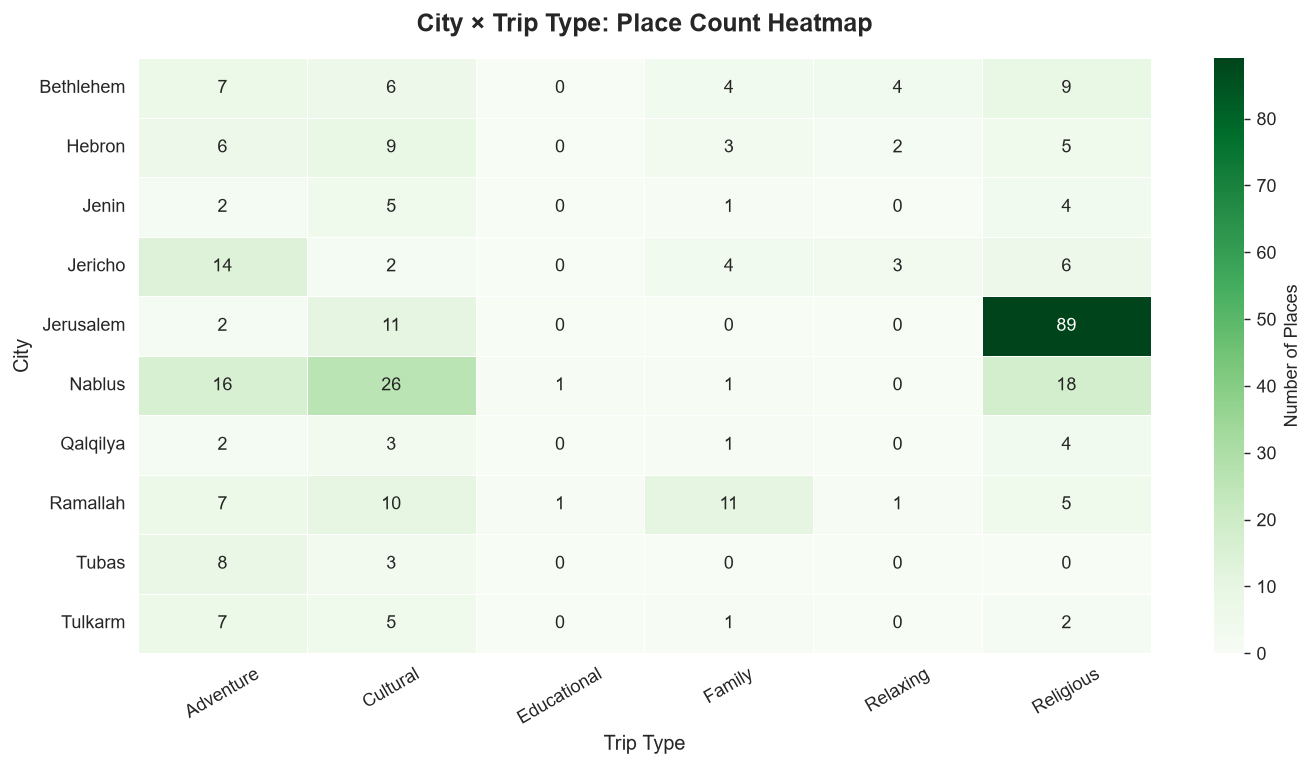


Cross-tabulation (raw counts):
Trip_Type  Adventure  Cultural  Educational  Family  Relaxing  Religious
City                                                                    
Bethlehem          7         6            0       4         4          9
Hebron             6         9            0       3         2          5
Jenin              2         5            0       1         0          4
Jericho           14         2            0       4         3          6
Jerusalem          2        11            0       0         0         89
Nablus            16        26            1       1         0         18
Qalqilya           2         3            0       1         0          4
Ramallah           7        10            1      11         1          5
Tubas              8         3            0       0         0          0
Tulkarm            7         5            0       1         0          2


In [8]:
ct = pd.crosstab(df['City'], df['Trip_Type'])

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    ct,
    annot=True,
    fmt='d',
    cmap='Greens',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Number of Places'}
)
ax.set_title('City × Trip Type: Place Count Heatmap', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Trip Type', fontsize=11)
ax.set_ylabel('City', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

print('\nCross-tabulation (raw counts):')
print(ct.to_string())

###  Key Observations
- **Jerusalem + Religious** is by far the strongest combination (89 places) — the model will excel here.
- **Nablus + Cultural** (26) and **Nablus + Adventure** (16) are strong pairs, making Nablus versatile.
- **Jericho + Adventure** (14) stands out as Jericho's specialty — unique for an outdoor audience.
- **Educational** trips only exist in Nablus (1) and Ramallah (1) — effectively a limitation of the dataset.
- Several cells are **zero**: e.g., Jerusalem has no Relaxing or Family places in the dataset. A user asking for Family trips in Jerusalem will get no results — something to communicate clearly in the UI.

## 7. Cost Analysis <a id='7'></a>

Understanding the cost distribution helps calibrate the budget filter in our recommendation system and sets user expectations about affordability.

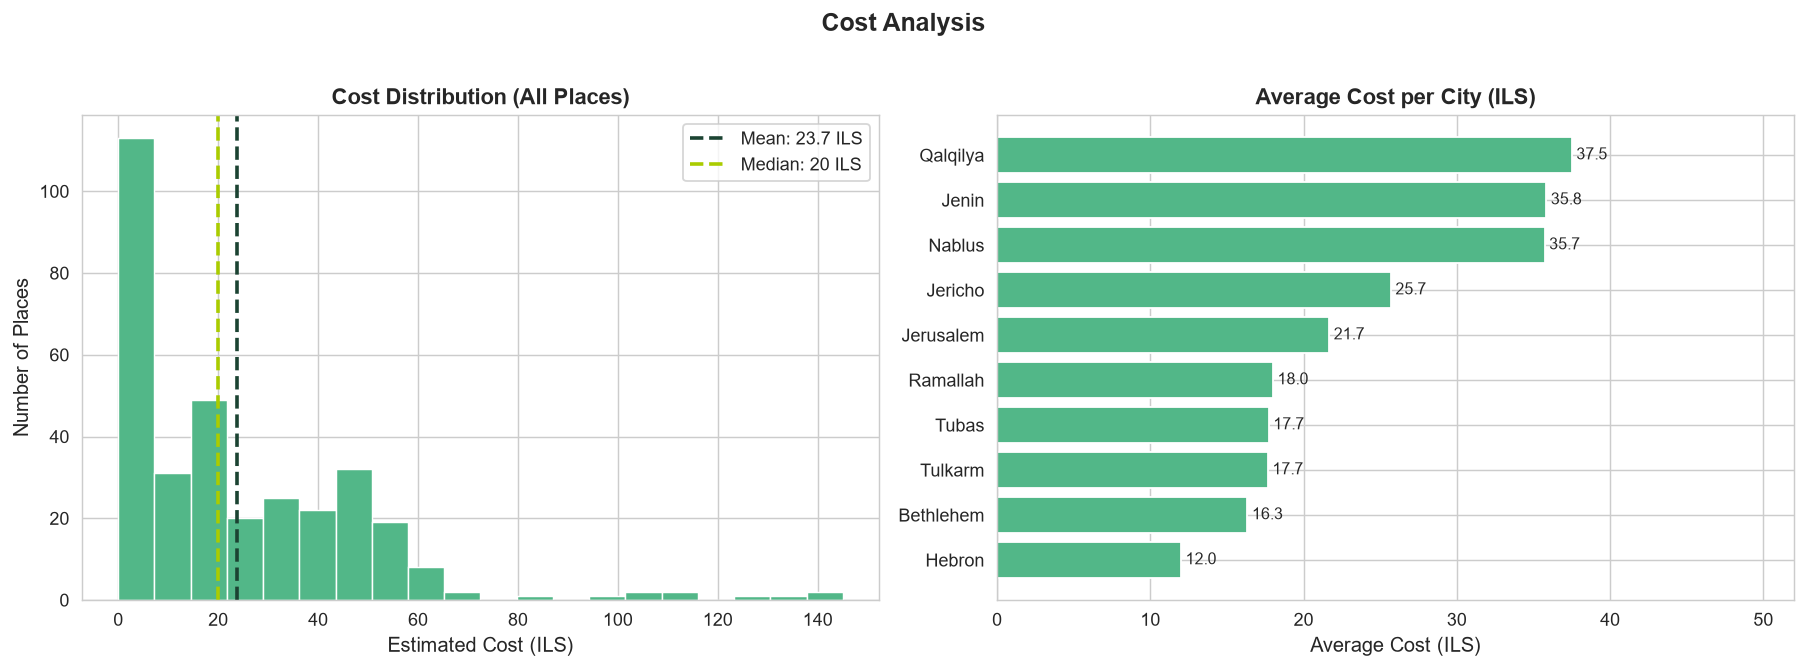

=== Cost Statistics ===
count    331.00
mean      23.73
std       25.66
min        0.00
25%        0.00
50%       20.00
75%       40.00
max      145.00
Name: Estimated_Cost_ILS, dtype: float64

Free places (0 ILS): 89 (26.9%)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Histogram ─────────────────────────────────────────────────────────────
axes[0].hist(
    df['Estimated_Cost_ILS'],
    bins=20,
    color='#52B788',
    edgecolor='white',
    linewidth=0.8
)
axes[0].axvline(
    df['Estimated_Cost_ILS'].mean(), color='#1B4332',
    linestyle='--', linewidth=2,
    label=f"Mean: {df['Estimated_Cost_ILS'].mean():.1f} ILS"
)
axes[0].axvline(
    df['Estimated_Cost_ILS'].median(), color='#AACC00',
    linestyle='--', linewidth=2,
    label=f"Median: {df['Estimated_Cost_ILS'].median():.0f} ILS"
)
axes[0].set_title('Cost Distribution (All Places)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Estimated Cost (ILS)', fontsize=11)
axes[0].set_ylabel('Number of Places', fontsize=11)
axes[0].legend()

# ── Avg Cost per City ─────────────────────────────────────────────────────
avg_cost = df.groupby('City')['Estimated_Cost_ILS'].mean().sort_values(ascending=False)
axes[1].barh(avg_cost.index[::-1], avg_cost.values[::-1], color='#52B788')
for i, (city, val) in enumerate(zip(avg_cost.index[::-1], avg_cost.values[::-1])):
    axes[1].text(val + 0.3, i, f'{val:.1f}', va='center', fontsize=9)
axes[1].set_title('Average Cost per City (ILS)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Cost (ILS)', fontsize=11)
axes[1].set_xlim(0, 52)

plt.suptitle('Cost Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('=== Cost Statistics ===')
print(df['Estimated_Cost_ILS'].describe().round(2))
print(f"\nFree places (0 ILS): {(df['Estimated_Cost_ILS']==0).sum()} "
      f"({(df['Estimated_Cost_ILS']==0).mean()*100:.1f}%)")

###  Key Observations
- The distribution is **right-skewed**: the median (20 ILS) is much lower than the mean (23.7 ILS), pulled up by a small number of expensive places (up to 145 ILS).
- **28.4% of places are completely free** — a major strength for budget-conscious travelers.
- **Qalqilya (37.5 ILS avg)** and **Jenin (35.8 ILS avg)** are the priciest cities on average.
- **Hebron (12 ILS avg)** and **Bethlehem (16.3 ILS avg)** offer the most affordable experiences.
- For the recommendation system: a group budget input is crucial — a family of 5 visiting a 40 ILS place pays 200 ILS total, which may exceed their budget even if the per-person cost seems low.

## 8. Budget Mix per City <a id='8'></a>

This stacked bar chart shows the proportion of Low/Medium/High budget places in each city, revealing which cities cater to which economic profile.

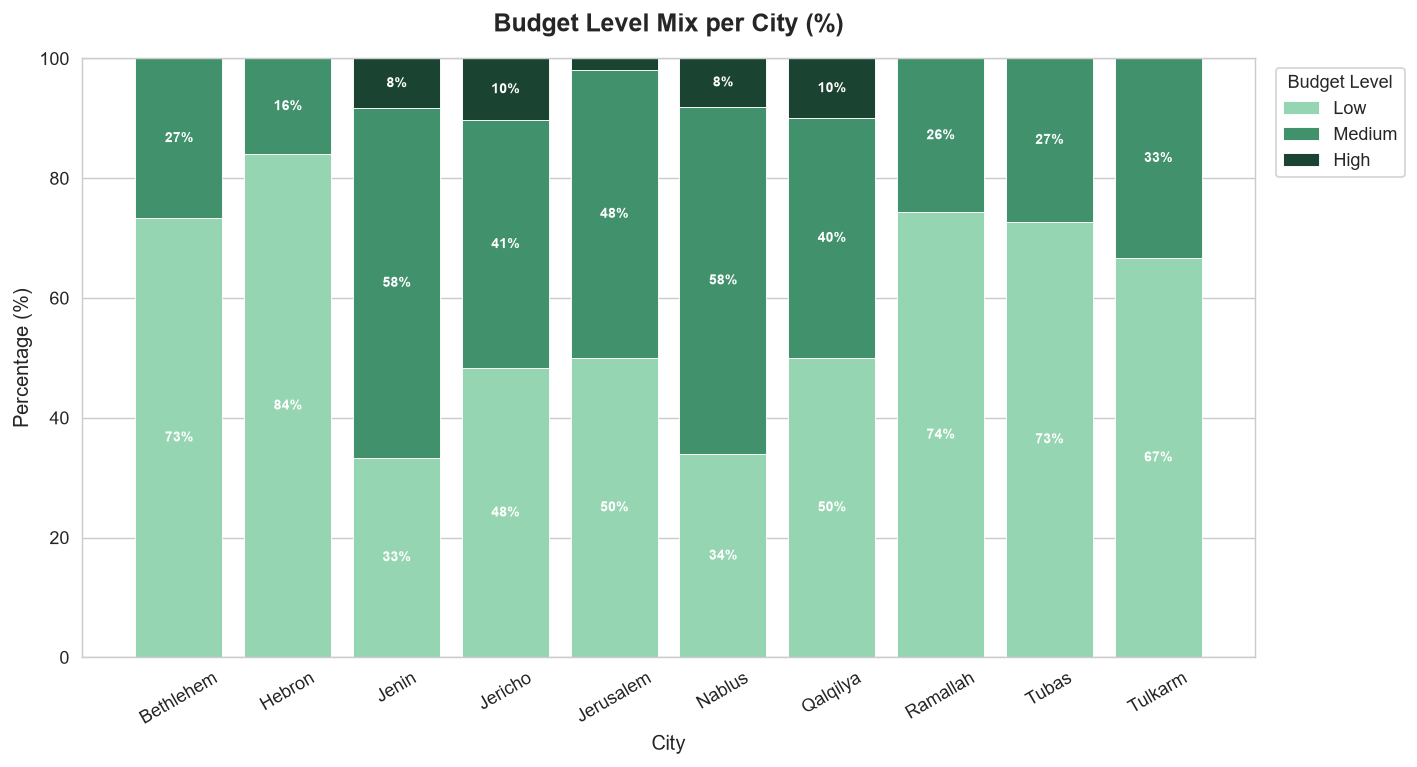


Budget mix per city (%):
Budget_Level  High   Low  Medium
City                            
Bethlehem      0.0  73.3    26.7
Hebron         0.0  84.0    16.0
Jenin          8.3  33.3    58.3
Jericho       10.3  48.3    41.4
Jerusalem      2.0  50.0    48.0
Nablus         8.1  33.9    58.1
Qalqilya      10.0  50.0    40.0
Ramallah       0.0  74.3    25.7
Tubas          0.0  72.7    27.3
Tulkarm        0.0  66.7    33.3


In [10]:
cb = pd.crosstab(df['City'], df['Budget_Level'])
cb_pct = cb.div(cb.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 6))
bottom = np.zeros(len(cb_pct))
budget_colors = {'Low': '#95D5B2', 'Medium': '#40916C', 'High': '#1B4332'}

for budget_level in ['Low', 'Medium', 'High']:
    if budget_level in cb_pct.columns:
        vals = cb_pct[budget_level].values
        ax.bar(
            cb_pct.index, vals, bottom=bottom,
            color=budget_colors[budget_level],
            label=budget_level,
            edgecolor='white', linewidth=0.5
        )
        for j, (v, b) in enumerate(zip(vals, bottom)):
            if v > 5:
                ax.text(
                    j, b + v/2, f'{v:.0f}%',
                    ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold'
                )
        bottom += vals

ax.set_title('Budget Level Mix per City (%)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xlabel('City', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Budget Level', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('\nBudget mix per city (%):')
print(cb_pct.round(1).to_string())

###  Key Observations
- **Ramallah and Hebron** are heavily Low-budget (74%+ of places), making them ideal for budget travelers.
- **Nablus** has the most balanced mix (~34% Low, 58% Medium, 8% High), giving it the widest appeal across budget ranges.
- **Jenin** is mostly Medium budget (58%) — a mid-tier destination.
- **High-budget places are rare everywhere** — only Nablus (5), Jericho (3), and Jerusalem (2) have any.
- For the recommendation system: when a user selects 'High' budget in most cities, results will be very limited. The UI should warn users about this.

## 9. Free Places Analysis <a id='9'></a>

Free places (0 ILS cost) are especially valuable for families and budget travelers. Here we measure which cities offer the most free access.

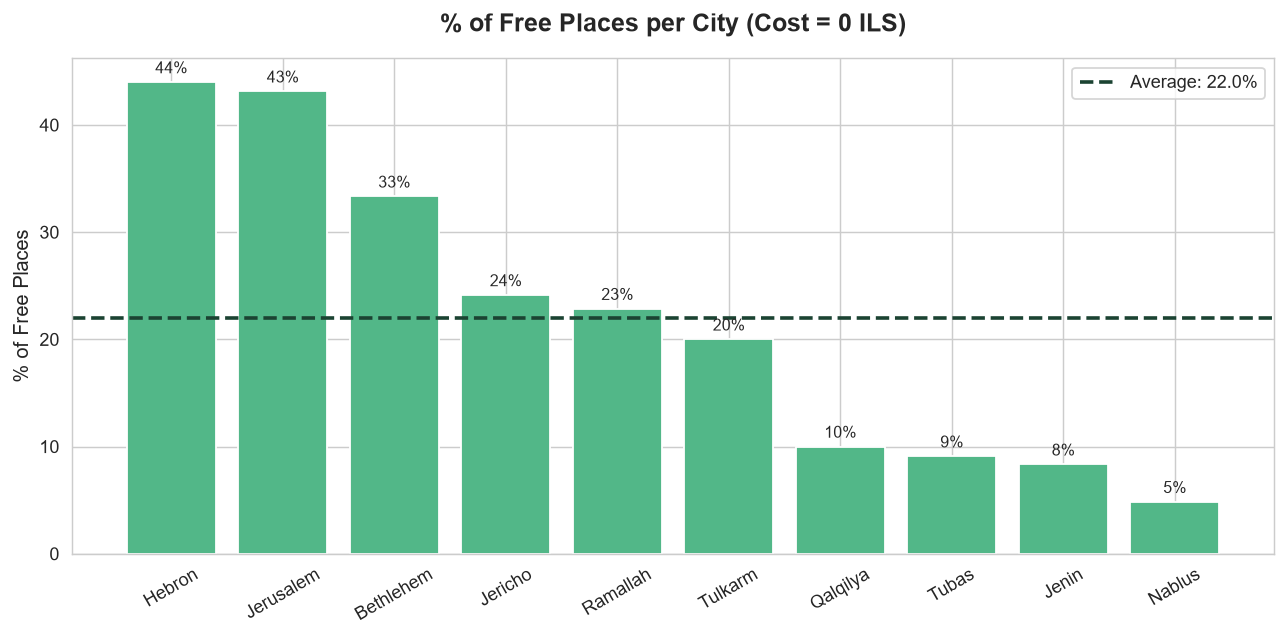


Free places by city:
           Total  Free  Free %
City                          
Hebron        25    11    44.0
Jerusalem    102    44    43.1
Bethlehem     30    10    33.3
Jericho       29     7    24.1
Ramallah      35     8    22.9
Tulkarm       15     3    20.0
Qalqilya      10     1    10.0
Tubas         11     1     9.1
Jenin         12     1     8.3
Nablus        62     3     4.8


In [11]:
free_df = df[df['Estimated_Cost_ILS'] == 0]
free_by_city  = free_df['City'].value_counts()
total_by_city = df['City'].value_counts()
free_pct = (free_by_city / total_by_city * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(free_pct.index, free_pct.values, color='#52B788', edgecolor='white')
ax.axhline(
    free_pct.mean(), color='#1B4332', linestyle='--', linewidth=2,
    label=f'Average: {free_pct.mean():.1f}%'
)
for bar, val in zip(bars, free_pct.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.0f}%',
        ha='center', va='bottom', fontsize=9
    )
ax.set_title('% of Free Places per City (Cost = 0 ILS)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('% of Free Places', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

print('\nFree places by city:')
summary = pd.DataFrame({
    'Total': total_by_city,
    'Free': free_by_city.reindex(total_by_city.index, fill_value=0),
    'Free %': free_pct.reindex(total_by_city.index, fill_value=0).round(1)
})
print(summary.sort_values('Free %', ascending=False).to_string())

###  Key Observations
- **Hebron leads with 44% free places** — nearly half of its attractions cost nothing.
- **Bethlehem (33%) and Ramallah (23%)** also offer significant free access, partly due to religious and public cultural sites.
- **Tubas (9%) and Qalqilya (10%)** have very few free options — visitors should plan a budget.
- On average, about **28% of all places** in the dataset are free — a strong selling point for the app.

## 10. Key Insights & Implications for the Recommendation Model <a id='10'></a>

---

###  Summary Table

| Insight | Impact on Model |
|---|---|
| Jerusalem has 31% of all places | Recommendations skewed toward Jerusalem without balancing |
| 42% of places are Religious | Religious users get the most options; model performs best here |
| 28% of places are free | Budget filter is highly useful; many places = 0 cost |
| Educational trip type: only 2 places | Very limited recommendations for educational trips |
| High budget: only 12 places (3.6%) | High-budget filter returns almost nothing |
| Jerusalem has 0 Family/Relaxing places | Zero results for these combos — needs graceful UI handling |
| Nablus: most balanced city | Best city for diverse multi-type recommendations |

---

###  What the Model Does Well
- Religious + Cultural trips in Jerusalem and Nablus → **High confidence, many options**
- Adventure trips in Jericho, Nablus, Tubas → **Good variety**
- Budget filtering → **Meaningful for most users (Low/Medium dominant)**
- Multi-city selection → **Increases result pool significantly**

###  Known Limitations to Address
- **Data imbalance by city**: Smaller cities (Tubas, Qalqilya) will always return fewer results.
- **Rare categories**: Educational and High-budget filters should show a warning in the UI.
- **Zero-result combos**: Certain city + trip_type combos don't exist — handle gracefully.
- **No user feedback data**: Without ratings or click history, we can't do collaborative filtering.

###  Future Improvements
- Add more places for underrepresented cities (Tubas, Qalqilya, Jenin)
- Incorporate TF-IDF on `Description` for richer semantic matching
- Collect user ratings to enable hybrid collaborative + content-based filtering
- Add seasonal or time-based features (opening hours, best season to visit)